In [33]:
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


# Carregar os dados que já preparaste
X_train = np.load("../data/X_train.npy")
y_train = np.load("../data/y_train.npy")
X_val = np.load("../data/X_val.npy")
y_val = np.load("../data/y_val.npy")
X_test = np.load("../data/X_test.npy") 
y_test = np.load("../data/y_test.npy") 

scaler_features = joblib.load('../models/scaler_features.joblib')
scaler_target = joblib.load('../models/scaler_target.joblib')

print(f"Dados carregados: {X_train.shape}")

Dados carregados: (9926, 7, 14)


In [34]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # 1. Camada de Atenção (Multi-Head Attention)
    # Aqui a IA foca-se em diferentes partes da sequência de 7 dias
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs # Conexão Residual: evita perda de sinal matemático

    # 2. Feed Forward Network (Processamento de cada dia individualmente)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res # Outra Conexão Residual

In [35]:
input_shape = (X_train.shape[1], X_train.shape[2]) # (7 dias, 10 colunas)
inputs = layers.Input(shape=input_shape)

# Aplicamos 2 blocos de Transformer para profundidade
x = transformer_encoder(inputs, head_size=256, num_heads=4, ff_dim=4, dropout=0.1)
x = transformer_encoder(x, head_size=256, num_heads=4, ff_dim=4, dropout=0.1)

# "Achatamos" a sequência para uma decisão final
x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)

# Camadas Densas (o toque final de lógica)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x) # 1 Único valor: Temp Max de amanhã

model_tf = models.Model(inputs, outputs)
model_tf.compile(optimizer="adam", loss="mse", metrics=["mae"])

model_tf.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 7, 14)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 14)     │     60,430 │ input_layer_5[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 7, 14)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 14)     │         28 │ dropout_33[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 7, 14)     │          0 │ layer_normalizat… │
│                     │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 7, 4)      │         60 │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 7, 4)      │          0 │ conv1d_18[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 7, 14)     │         70 │ dropout_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 14)     │         28 │ conv1d_19[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 7, 14)     │          0 │ layer_normalizat… │
│                     │                   │            │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 14)     │     60,430 │ add_19[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 7, 14)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 14)     │         28 │ dropout_36[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 7, 14)     │          0 │ layer_normalizat… │
│                     │                   │            │ add_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 7, 4)      │         60 │ add_20[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 7, 4)      │          0 │ conv1d_20[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 7, 14)     │         70 │ dropout_37[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 14)     │         28 │ conv1d_21[0][0]   │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 122,257 (477.57 KB)

 Trainable params: 122,257 (477.57 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
print("A iniciar o treino do Transformer...")
history_tf = model_tf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60, # Transformers às vezes precisam de um pouco mais de tempo
    batch_size=32,
    verbose=1
)

A iniciar o treino do Transformer...
Epoch 1/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0395 - mae: 0.1156 - val_loss: 0.0098 - val_mae: 0.0752
Epoch 2/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0093 - mae: 0.0744 - val_loss: 0.0097 - val_mae: 0.0741
Epoch 3/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0081 - mae: 0.0693 - val_loss: 0.0101 - val_mae: 0.0755
Epoch 4/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0078 - mae: 0.0679 - val_loss: 0.0098 - val_mae: 0.0749
Epoch 5/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0072 - mae: 0.0651 - val_loss: 0.0112 - val_mae: 0.0800
Epoch 6/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0072 - mae: 0.0649 - val_loss: 0.0089 - val_mae: 0.0726
Epoch 7/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0070 - mae: 0.0639 - val_loss: 0.0101 - val_mae: 0.0761
Epoch 8/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0066 - mae: 0.0621 - val_loss: 0.0097 - val_mae: 0.0746
Epoch 9/60
311/311 

In [37]:
from sklearn.metrics import mean_absolute_error

# 1. Fazer previsões
y_pred_scaled = model_tf.predict(X_test)

# 2. Reverter para Celsius
y_pred = scaler_target.inverse_transform(y_pred_scaled)
y_real = scaler_target.inverse_transform(y_test)

# 3. Calcular Erro Médio (MAE)
mae_tf = mean_absolute_error(y_real, y_pred)
print(f"\n--- PERFORMANCE DO TRANSFORMER ---")
print(f"Erro Médio Absoluto (MAE): {mae_tf:.2f}°C")

# 4. Guardar o modelo
model_tf.save('../models/weather_predictor_transformer.keras')
print("Modelo guardado com sucesso!")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

--- PERFORMANCE DO TRANSFORMER ---
Erro Médio Absoluto (MAE): 2.34°C
Modelo guardado com sucesso!


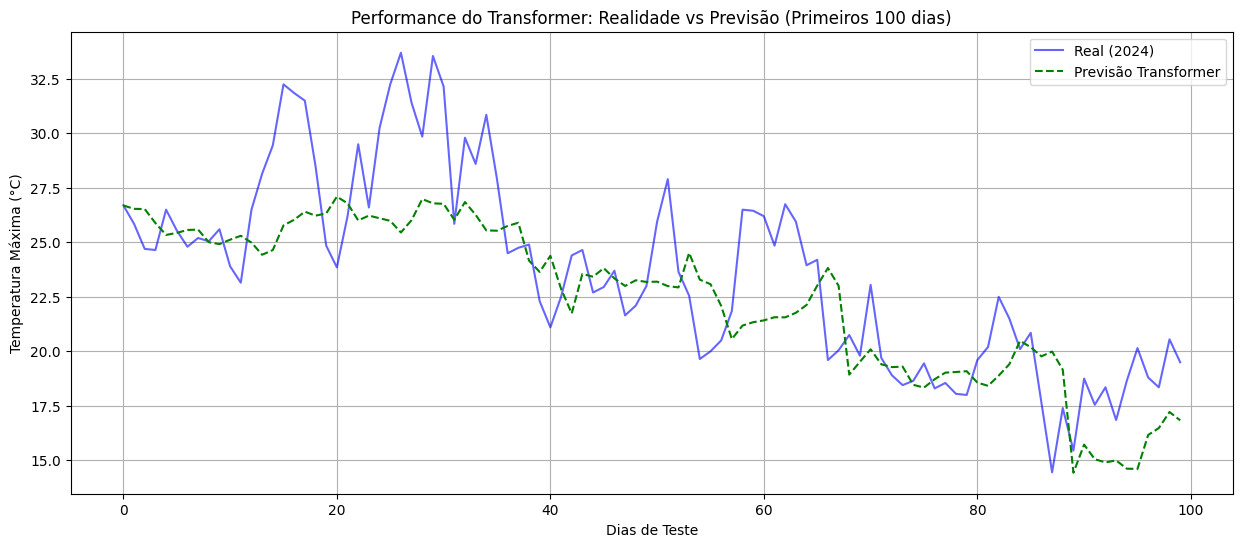

In [38]:
plt.figure(figsize=(15, 6))
plt.plot(y_real[:100], label='Real (2024)', color='blue', alpha=0.6)
plt.plot(y_pred[:100], label='Previsão Transformer', color='green', linestyle='--')
plt.title('Performance do Transformer: Realidade vs Previsão (Primeiros 100 dias)')
plt.xlabel('Dias de Teste')
plt.ylabel('Temperatura Máxima (°C)')
plt.legend()
plt.grid(True)
plt.show()